# Week 4 Capstone: repaired evidence review

The original Week 4 archive is absent and its saved outputs show cross-function corruption. This notebook therefore uses all **191 confirmed observations** (starter data plus Week 1 and Week 2 returns), marks the unavailable Week 3 return as pending, and produces reproducible Week 4 proposals without fabricating evidence.

## Errors found and corrected

1. `week_4_data.zip` is absent, so the first cell always fails.
2. Saved outputs prove the missing archive was corrupted: F1/F3/F7 share an impossible maximum of `64`, F4 contains F2's return, F6 contains F3's return, and F8 loses confirmed best values.
3. The corruption follows the earlier truncated F8 input and flattened-value misalignment; data must be grouped by function and dimension, never flattened globally.
4. Exact Week 3 returned queries/outputs are not stored in this repository. They are labelled pending rather than guessed.
5. Raw `np.random` made proposals irreproducible, and rounded points were not checked for collisions. Function-specific generators and post-rounding checks are used.
6. The GP used only a fixed RBF and discarded kernel, uncertainty, and UCB diagnostics. A fitted composite kernel now returns all diagnostics.
7. Function 5 was hard-coded to `[0,0,0,0]` without evidence. It now explores locally around the confirmed best.
8. Output plots omitted running best and all feature relationships. Complete function diagnostics and a cross-function overview are included.
9. Shape, count, finiteness, domain, round-order, and proposal checks were missing and are now enforced.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

FUNCTIONS = tuple(range(1, 9))
DIMS = {1:2, 2:2, 3:3, 4:4, 5:4, 6:5, 7:6, 8:8}
STRATEGY = {i: ('Manual Reasoning' if i == 5 else 'Bayesian Optimisation') for i in FUNCTIONS}
KAPPA = {1:5., 2:5., 3:5., 4:5., 6:5., 7:3., 8:2.}
QUERIES = {
1:[[.375440,.950714],[.536429,.835362]],
2:[[.375440,.950714],[.978752,.932731]],
3:[[.444444,.666666,.333333],[.657452,.998464,.817253]],
4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202]],
5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260]],
6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321]],
7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324]],
8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846]]}
OUTPUTS = {
1:[-1.560646704467778e-117,1.674933466363685e-36],
2:[-.03182956281754251,.022666631114895516],
3:[-.04090761844901528,-.08987474979637637],
4:[-8.727516493155957,-31.73535839431216],
5:[1088.8535114737463,1035.6341457754475],
6:[-1.1520351120911565,-.8782405650300305],
7:[1.0510148516295004,.308765180253091],
8:[9.8157087929671,9.9399041910574]}

def find_root(start=None):
    current = Path.cwd() if start is None else Path(start).expanduser().resolve()
    for candidate in (current, *current.parents):
        if (candidate/'Week_01').is_dir() and (candidate/'Week_04').is_dir(): return candidate
    raise FileNotFoundError('Capstone repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid')
print(f'Repository root: {ROOT}')
print('Evidence status: Week 3 returned observations are unavailable; analysis uses confirmed data through Week 3.')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial
Evidence status: Week 3 returned observations are unavailable; analysis uses confirmed data through Week 3.


In [2]:
def validate(fn, X, y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}) inputs; got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: counts must match and be non-empty.')
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: non-finite data.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: inputs outside [0,1].')

def load_confirmed(fn):
    if fn not in FUNCTIONS: raise ValueError('Function number must be 1..8.')
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'
    input_file,output_file=folder/'initial_inputs.npy',folder/'initial_outputs.npy'
    if not input_file.is_file() or not output_file.is_file(): raise FileNotFoundError(f'F{fn}: starter files missing.')
    X=np.asarray(np.load(input_file),float); y=np.asarray(np.load(output_file),float).reshape(-1); validate(fn,X,y)
    for round_index,(query,output) in enumerate(zip(QUERIES[fn],OUTPUTS[fn]),start=1):
        query=np.asarray(query,float)
        if query.shape!=(DIMS[fn],): raise ValueError(f'F{fn}, round {round_index}: wrong dimension {query.shape}.')
        X=np.vstack((X,query)); y=np.append(y,output)
    validate(fn,X,y); return X,y

## Function-by-function confirmed evidence

`Latest confirmed observation` is the Week 2 return recorded in the Week 3 notebook. The missing Week 3 return is explicitly `Pending`. Negative maxima are valid because each objective is being maximised.

In [3]:
def summarize(fn):
    X,y=load_confirmed(fn); previous=y[:-1]; best=int(np.argmax(y))
    return {'Function':f'F{fn}','Strategy':STRATEGY[fn],'Dimensions':X.shape[1],'Confirmed observations':len(y),
            'Previous best':float(np.max(previous)),'Latest confirmed observation':float(y[-1]),
            'Confirmed best':float(y[best]),'Latest improvement':float(np.max(y)-np.max(previous)),
            'Latest percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),
            'Week 3 return status':'Pending — source data unavailable'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Strategy,Dimensions,Confirmed observations,Previous best,Latest confirmed observation,Confirmed best,Latest improvement,Latest percentile,Best query,Best input,Week 3 return status
0,F1,Bayesian Optimisation,2,12,7.710875e-16,1.674933e-36,7.710875e-16,0.000000,90.909091,3,"[0.7310236309563586, 0.7329998764152272]",Pending — source data unavailable
1,F2,Bayesian Optimisation,2,12,6.112052e-01,2.266663e-02,6.112052e-01,0.000000,27.272727,10,"[0.7026365569244406, 0.9265641975455574]",Pending — source data unavailable
2,F3,Bayesian Optimisation,3,17,-3.483531e-02,-8.987475e-02,-3.483531e-02,0.000000,56.250000,4,"[0.49258141463713434, 0.6115931882759961, 0.34...",Pending — source data unavailable
3,F4,Bayesian Optimisation,4,32,-4.025542e+00,-3.173536e+01,-4.025542e+00,0.000000,3.225806,28,"[0.5777656143780968, 0.4287717415443063, 0.425...",Pending — source data unavailable
4,F5,Manual Reasoning,4,22,1.088860e+03,1.035634e+03,1.088860e+03,0.000000,90.476190,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",Pending — source data unavailable
5,F6,Bayesian Optimisation,5,22,-7.142649e-01,-8.782406e-01,-7.142649e-01,0.000000,90.476190,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",Pending — source data unavailable
6,F7,Bayesian Optimisation,6,32,1.364968e+00,3.087652e-01,1.364968e+00,0.000000,74.193548,7,"[0.057895541971385245, 0.49167221863901367, 0....",Pending — source data unavailable
7,F8,Bayesian Optimisation,8,42,9.815709e+00,9.939904e+00,9.939904e+00,0.124195,100.000000,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...",Pending — source data unavailable


In [4]:
for row in performance.to_dict('records'):
    status='IMPROVED' if row['Latest improvement']>0 else 'NO NEW BEST'
    print(f"{row['Function']} — {row['Strategy']} — {status}")
    print(f"  confirmed observations={row['Confirmed observations']}, dimensions={row['Dimensions']}")
    print(f"  previous best={row['Previous best']:.12g}, latest={row['Latest confirmed observation']:.12g}")
    print(f"  confirmed best={row['Confirmed best']:.12g}, improvement={row['Latest improvement']:.12g}")
    print(f"  Week 3 return: {row['Week 3 return status']}")

F1 — Bayesian Optimisation — NO NEW BEST
  confirmed observations=12, dimensions=2
  previous best=7.7108751145e-16, latest=1.67493346636e-36
  confirmed best=7.7108751145e-16, improvement=0
  Week 3 return: Pending — source data unavailable
F2 — Bayesian Optimisation — NO NEW BEST
  confirmed observations=12, dimensions=2
  previous best=0.611205215761, latest=0.0226666311149
  confirmed best=0.611205215761, improvement=0
  Week 3 return: Pending — source data unavailable
F3 — Bayesian Optimisation — NO NEW BEST
  confirmed observations=17, dimensions=3
  previous best=-0.0348353133501, latest=-0.0898747497964
  confirmed best=-0.0348353133501, improvement=0
  Week 3 return: Pending — source data unavailable
F4 — Bayesian Optimisation — NO NEW BEST
  confirmed observations=32, dimensions=4
  previous best=-4.02554228191, latest=-31.7353583943
  confirmed best=-4.02554228191, improvement=0
  Week 3 return: Pending — source data unavailable
F5 — Manual Reasoning — NO NEW BEST
  confirme

## Reproducible Week 4 proposals

These proposals use only confirmed evidence. Bayesian functions use GP-UCB; F5 uses bounded local exploration. All points are checked after six-decimal submission rounding.

In [5]:
def manual_query(X,y,rng):
    centre=X[int(np.argmax(y))]
    for _ in range(100):
        q=np.round(np.clip(centre+rng.normal(0,.05,centre.shape),0,1),6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)): return {'query':q,'kernel':'Manual reasoning','std':np.nan,'ucb':np.nan}
    raise RuntimeError('No distinct manual proposal found.')

def bayesian_query(X,y,kappa,rng,n=5000):
    d=X.shape[1]; kernel=ConstantKernel(1.,(1e-3,1e3))*RBF(np.ones(d),(1e-2,1e2))+WhiteKernel(1e-5,(1e-10,1e1))
    gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    candidates=rng.uniform(0,1,(n,d)); mean,std=gp.predict(candidates,return_std=True); ucb=mean+kappa*std
    for index in np.argsort(ucb)[::-1]:
        q=np.round(candidates[index],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)):
            return {'query':q,'kernel':str(gp.kernel_),'std':float(std[index]),'ucb':float(ucb[index])}
    raise RuntimeError('No distinct Bayesian proposal found.')

In [6]:
week_4_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_confirmed(fn); rng=np.random.default_rng(400+fn); kappa=np.nan if fn==5 else KAPPA[fn]
    result=manual_query(X,y,rng) if fn==5 else bayesian_query(X,y,kappa,rng)
    q=result['query']; assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1))
    week_4_queries[fn]=q
    rows.append({'Function':f'F{fn}','Method':STRATEGY[fn],'Kappa':kappa,'Proposed query':q.tolist(),
                 'Fitted kernel':result['kernel'],'Predictive std':result['std'],'UCB score':result['ucb'],
                 'Distance from confirmed best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Method,Kappa,Proposed query,Fitted kernel,Predictive std,UCB score,Distance from confirmed best
0,F1,Bayesian Optimisation,5.0,"[0.395297, 0.33411]","1.03**2 * RBF(length_scale=[100, 0.0291]) + Wh...",0.001026,0.004866,0.521369
1,F2,Bayesian Optimisation,5.0,"[0.699994, 0.598175]","0.527**2 * RBF(length_scale=[0.056, 0.431]) + ...",0.203154,1.346149,0.328400
2,F3,Bayesian Optimisation,5.0,"[0.991614, 0.004472, 0.634209]","1.5**2 * RBF(length_scale=[100, 0.96, 0.081]) ...",0.101879,0.415451,0.839098
3,F4,Bayesian Optimisation,5.0,"[0.380976, 0.395022, 0.344619, 0.438241]","2.09**2 * RBF(length_scale=[0.786, 0.721, 0.76...",0.583712,1.705815,0.286826
4,F5,Manual Reasoning,NaN,"[0.232408, 0.962649, 0.82905, 0.87741]",Manual reasoning,NaN,NaN,0.126915
5,F6,Bayesian Optimisation,5.0,"[0.173589, 0.008968, 0.161532, 0.003614, 0.341...","1.05**2 * RBF(length_scale=[100, 100, 100, 0.1...",0.468823,0.908580,1.101239
6,F7,Bayesian Optimisation,3.0,"[0.138028, 0.35901, 0.748416, 0.23308, 0.39305...","0.921**2 * RBF(length_scale=[0.879, 0.302, 100...",0.171468,1.761945,0.548794
7,F8,Bayesian Optimisation,2.0,"[0.000508, 0.353337, 0.042085, 0.218791, 0.947...","2.15**2 * RBF(length_scale=[0.974, 1.85, 0.897...",0.124516,10.147260,0.655764


## Complete Matplotlib diagnostics

Red diamonds show the latest confirmed observation; gold stars show the confirmed best. Feature panels are coloured by query order.

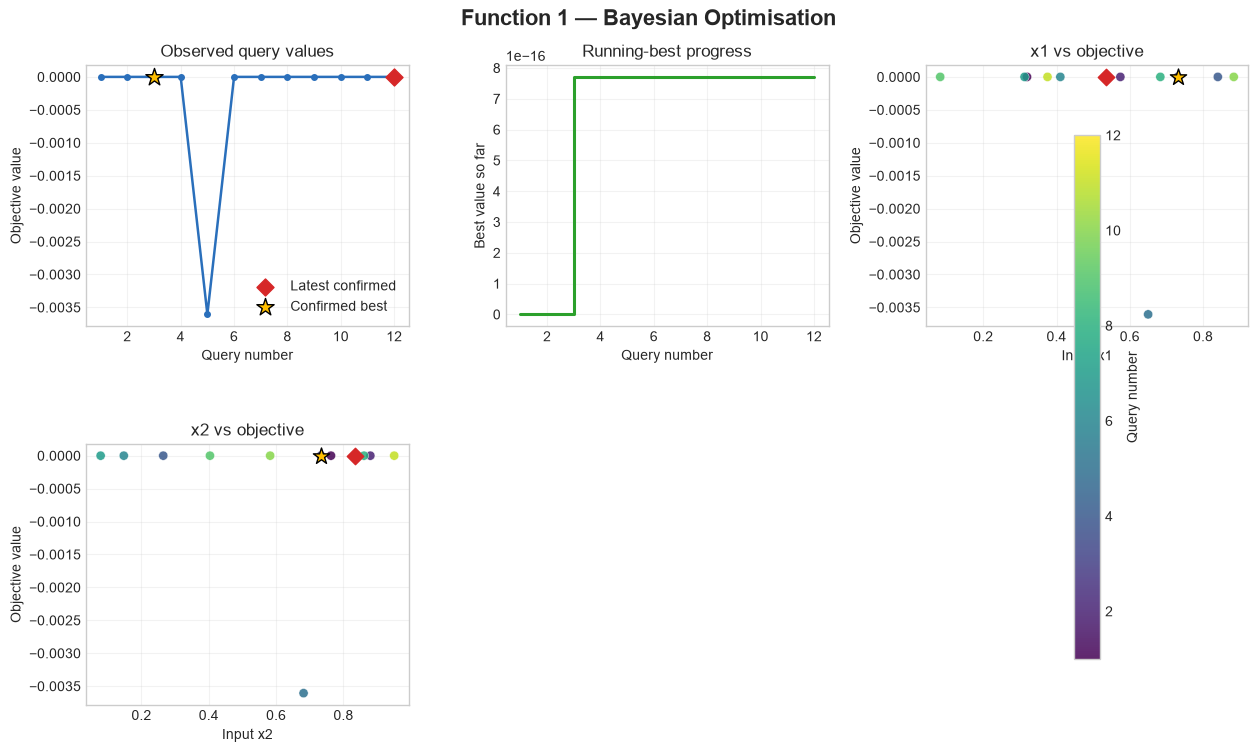

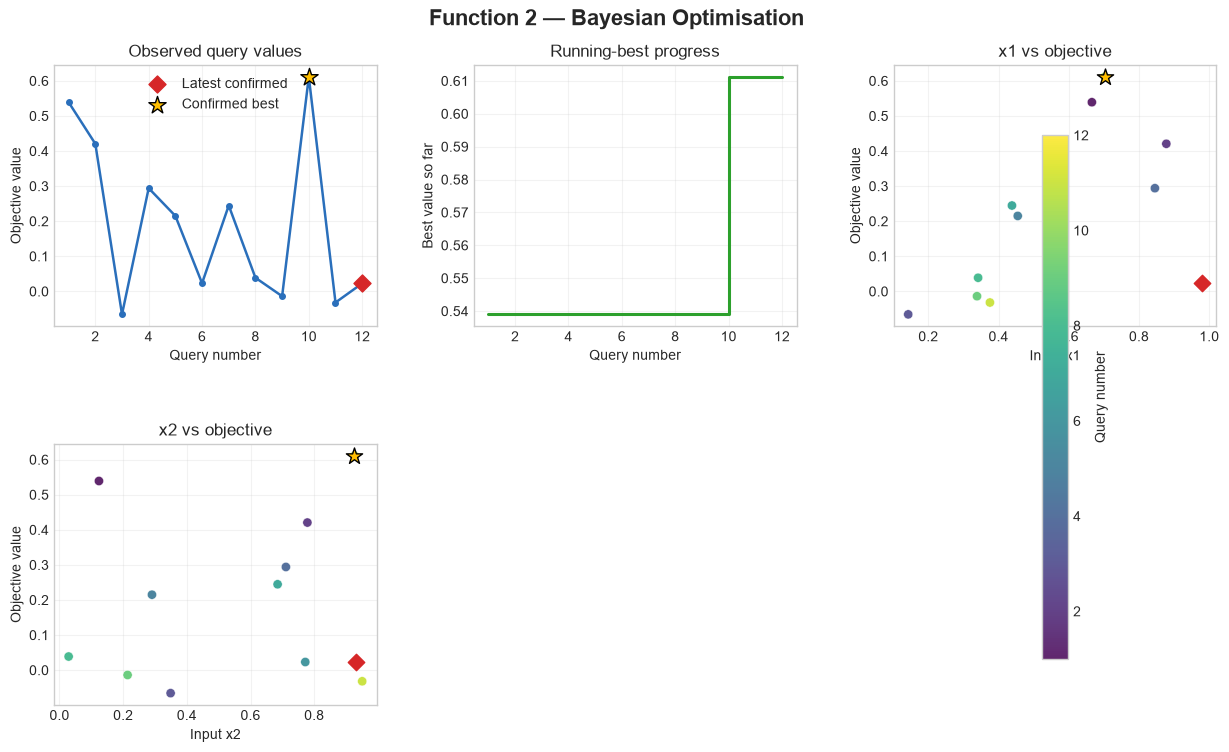

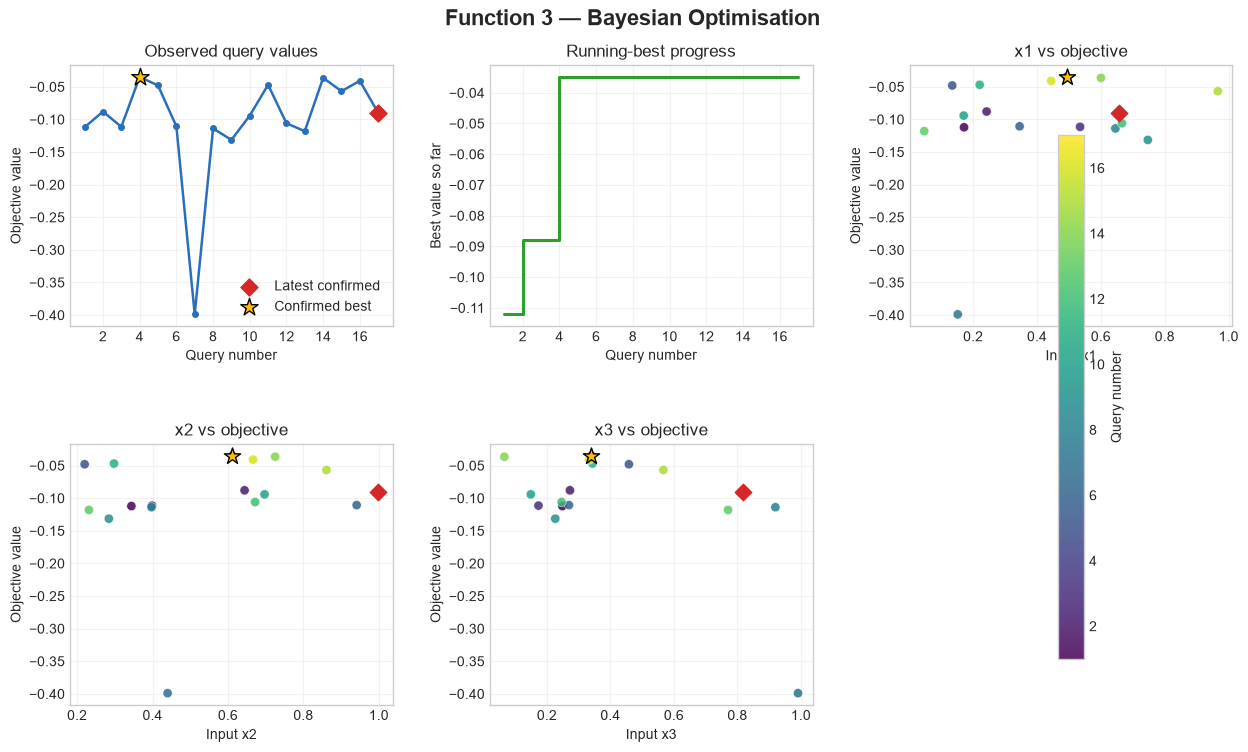

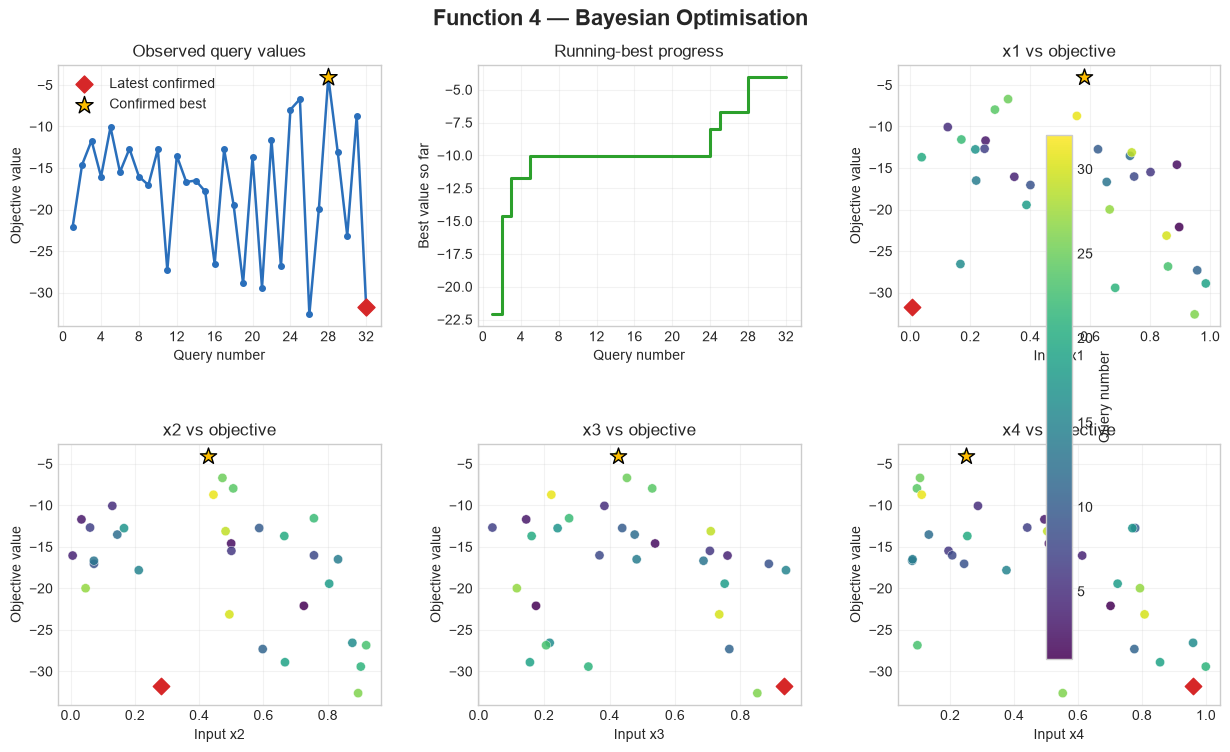

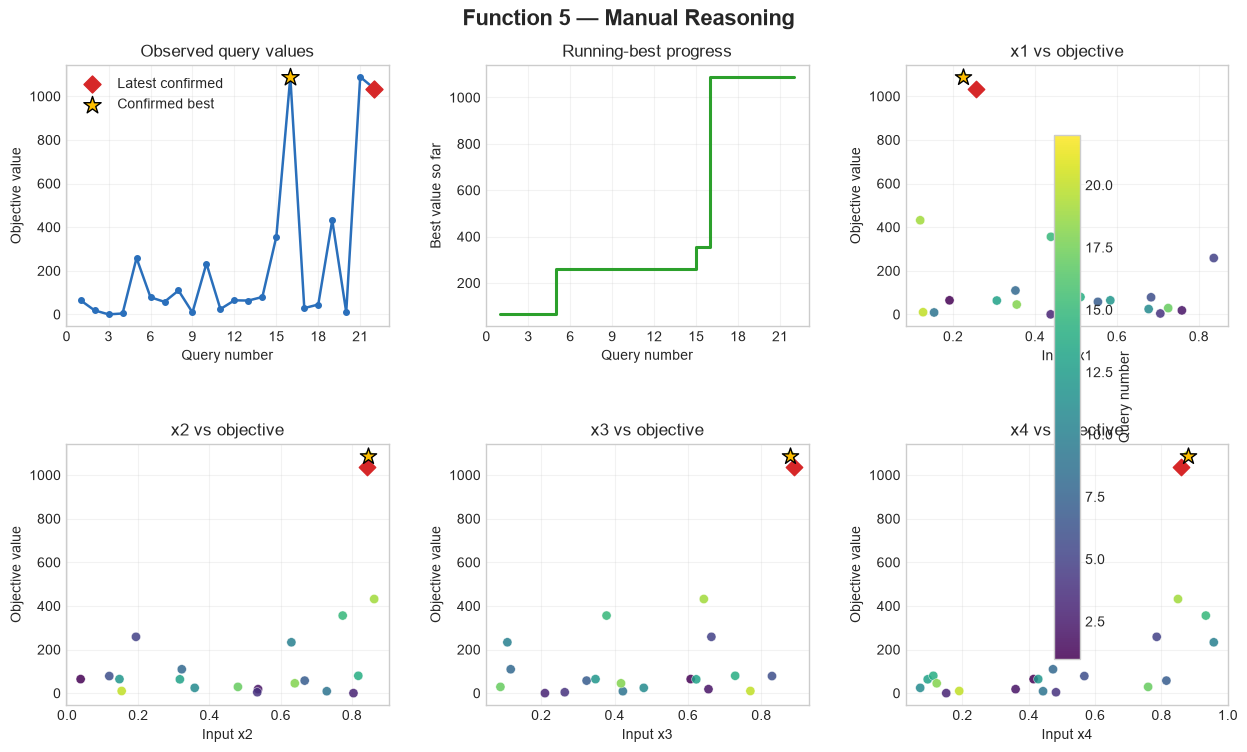

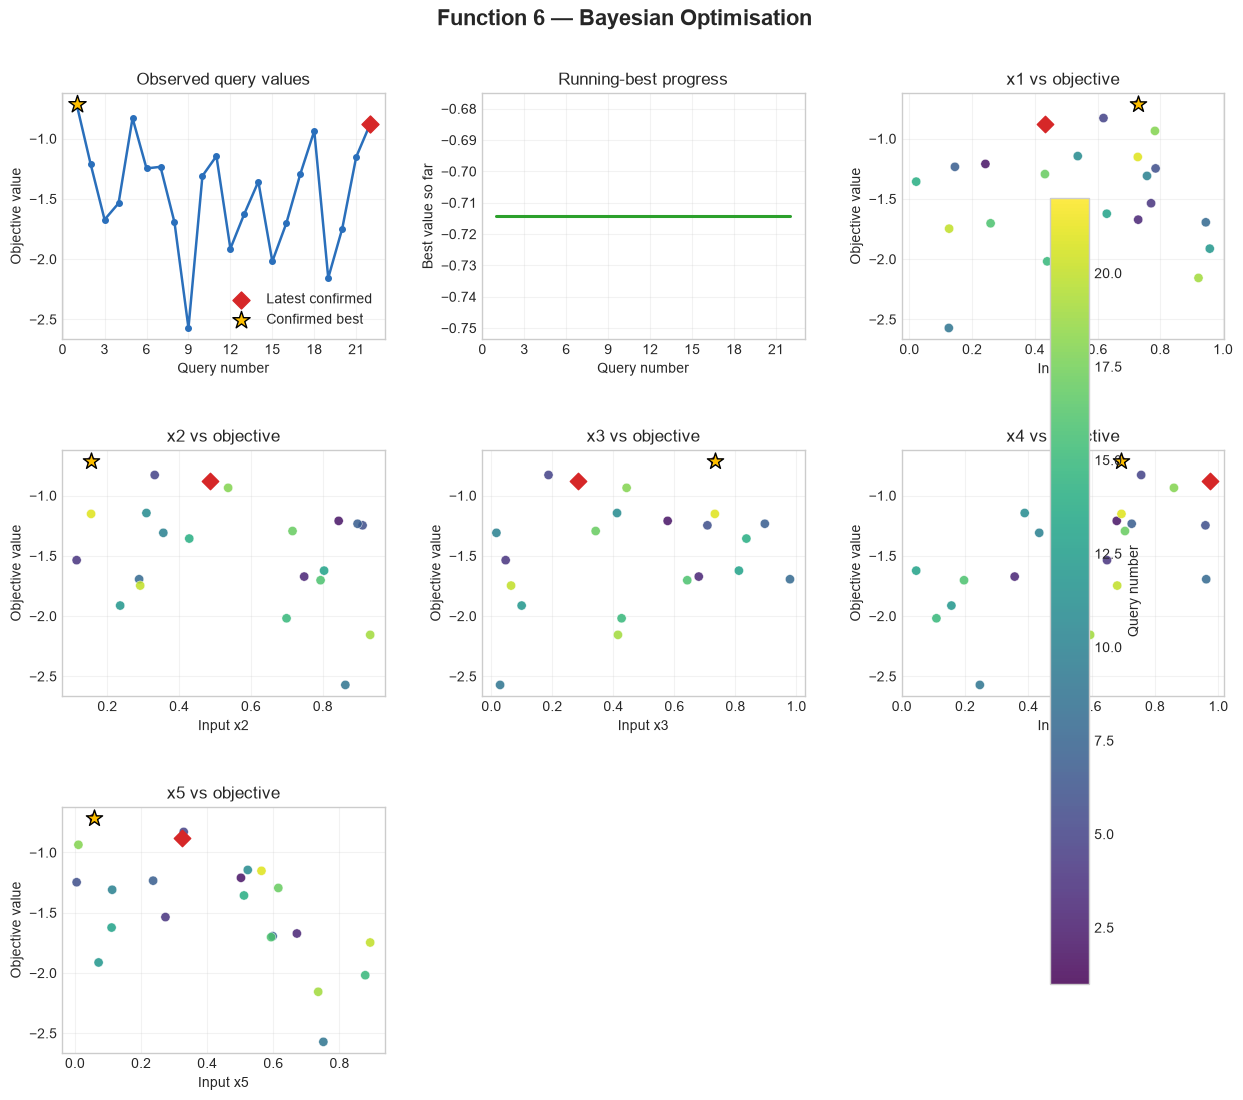

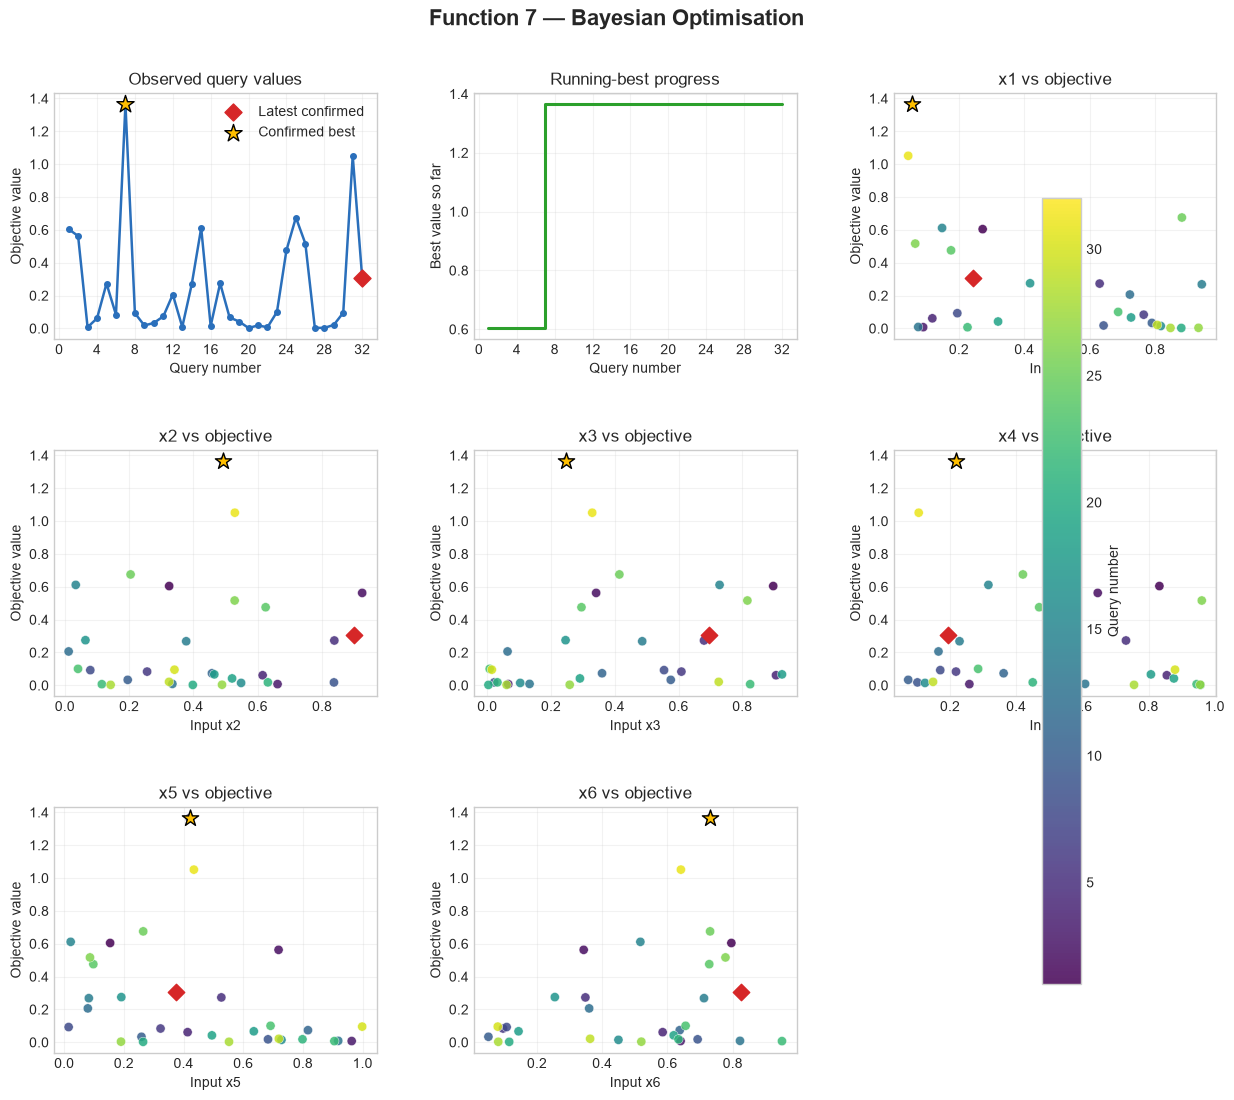

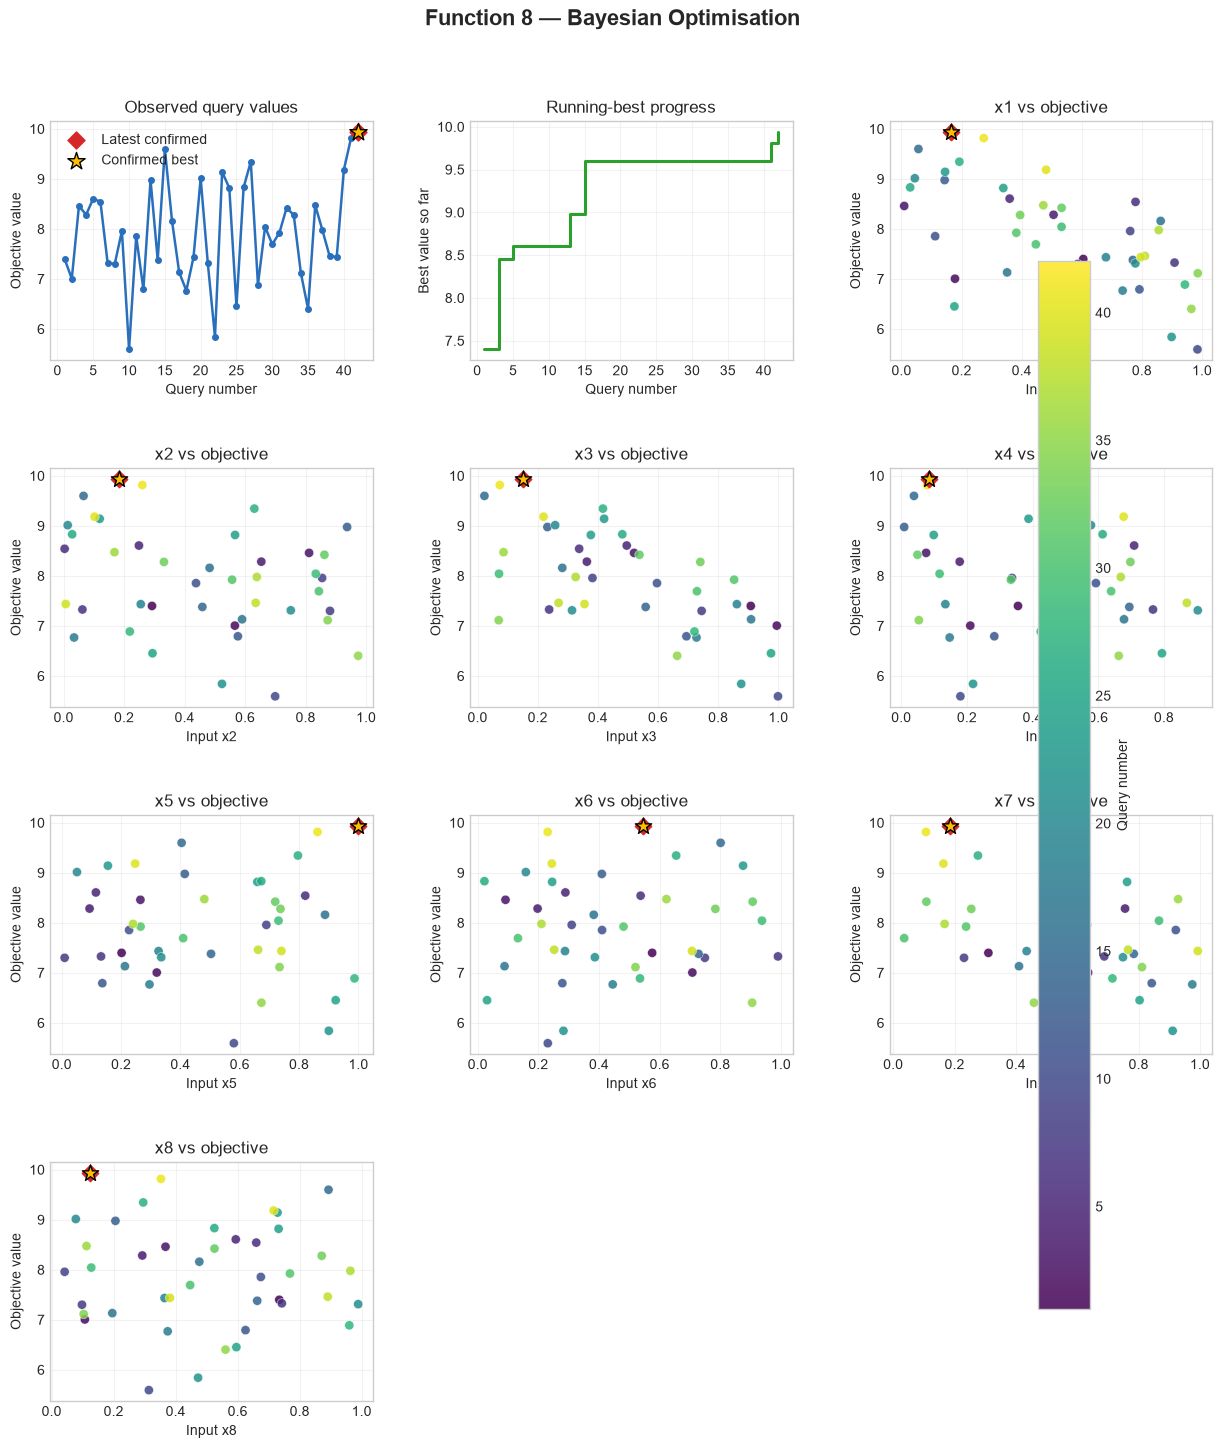

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_confirmed(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3
    fig,axes=plt.subplots(math.ceil(panels/cols),cols,figsize=(15,4*math.ceil(panels/cols)),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',linewidth=1.8,markersize=4)
    axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Latest confirmed')
    axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Confirmed best')
    axes[0].set(xlabel='Query number',ylabel='Objective value',title='Observed query values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    running=np.maximum.accumulate(y); axes[1].step(q,running,where='post',color='#2ca02c',linewidth=2.2)
    axes[1].set(xlabel='Query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]):
        colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',linewidth=.35)
        axis.scatter(X[-1,col],y[-1],marker='D',color='#d62728',s=70,zorder=4); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5)
        axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Query number',shrink=.85)
    fig.suptitle(f'Function {fn} — {STRATEGY[fn]}',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

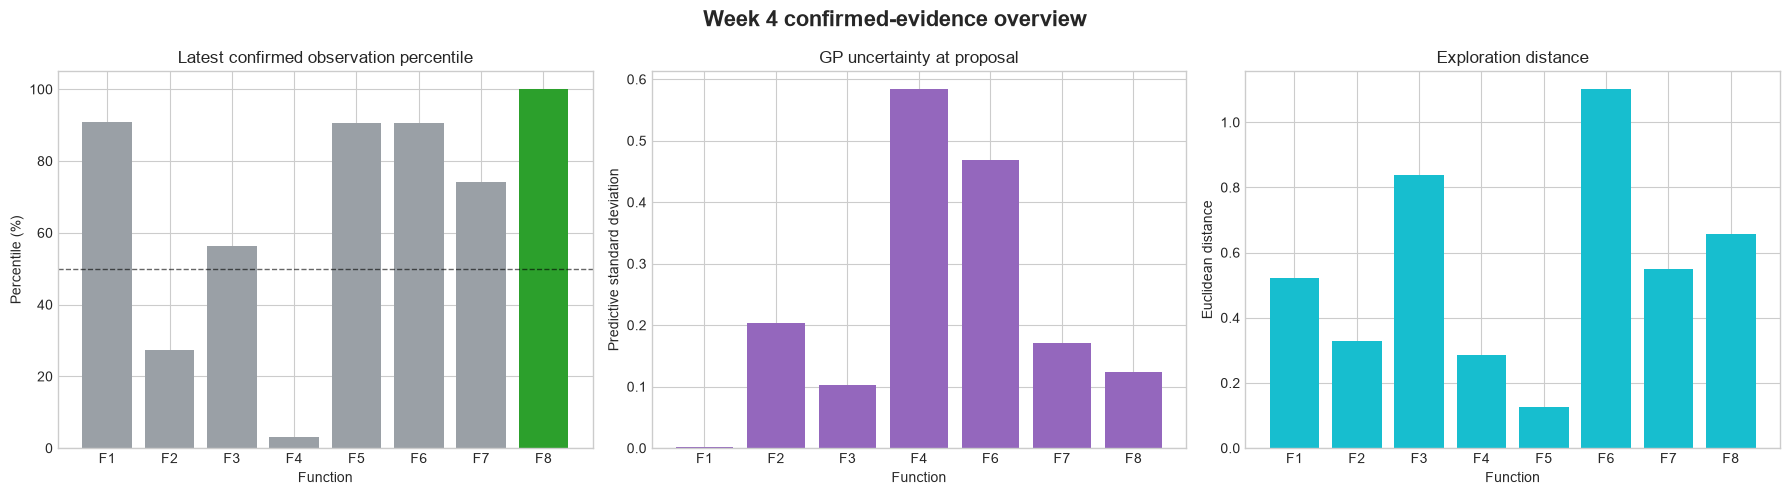

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
colours=np.where(performance['Latest improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Latest percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1,alpha=.6)
axes[0].set(title='Latest confirmed observation percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
gp=proposal_summary['Method'].eq('Bayesian Optimisation'); axes[1].bar(proposal_summary.loc[gp,'Function'],proposal_summary.loc[gp,'Predictive std'],color='#9467bd')
axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive standard deviation')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from confirmed best'],color='#17becf')
axes[2].set(title='Exploration distance',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 4 confirmed-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:12,2:12,3:17,4:32,5:22,6:22,7:32,8:42}
for fn in FUNCTIONS:
    X,y=load_confirmed(fn); s=summarize(fn); q=week_4_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],)
    assert np.allclose(X[-2:],QUERIES[fn]) and np.allclose(y[-2:],OUTPUTS[fn])
    assert s['Best query']==int(np.argmax(y))+1 and s['Latest improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1))
    assert not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==191 and len(performance)==len(proposal_summary)==len(week_4_queries)==8
assert performance['Week 3 return status'].str.startswith('Pending').all()
print('All Week 4 confirmed-data, performance, proposal, and plotting checks passed.')

All Week 4 confirmed-data, performance, proposal, and plotting checks passed.
